In [55]:
from hybrid_surr import plot_hyb
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import numpy as np
import arviz as az
import torch
from sklearn.metrics import r2_score, root_mean_squared_error, top_k_accuracy_score
#from io import BytesIO
from hybrid_surr import plot_funcs, aux_f,surr_funcs
warnings.filterwarnings(action='ignore')

# to account for updates when files change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [271]:
df = pd.read_csv('hybrid_surr/aux_hyb/sw_incidence_100k.csv')
_, df = train_test_split(df, test_size=2400, 
                                      random_state=42, stratify=None)

pt = df.iloc[:,5:].values.argmax(axis=1)+1
ph = df.iloc[:,5:].values.max(axis=1)

new_df = df.iloc[:,[0,4]]
new_df = new_df.round(2)
new_df['actual_peak_Inc'] = ph
new_df['actual_peak_day_Inc'] = pt
new_df

,beta,alpha,actual_peak_Inc,actual_peak_day_Inc
3098,0.49,0.79,1402.0,109
2531,0.42,0.72,936.0,164
4071,0.61,0.92,2430.0,100
1287,0.27,0.28,1.0,8
2540,0.42,0.81,1257.0,138
...,...,...,...,...
6865,0.96,0.86,2920.0,77
6356,0.80,0.57,1288.0,105
3378,0.53,0.39,303.0,220
4032,0.61,0.53,813.0,140


## plots

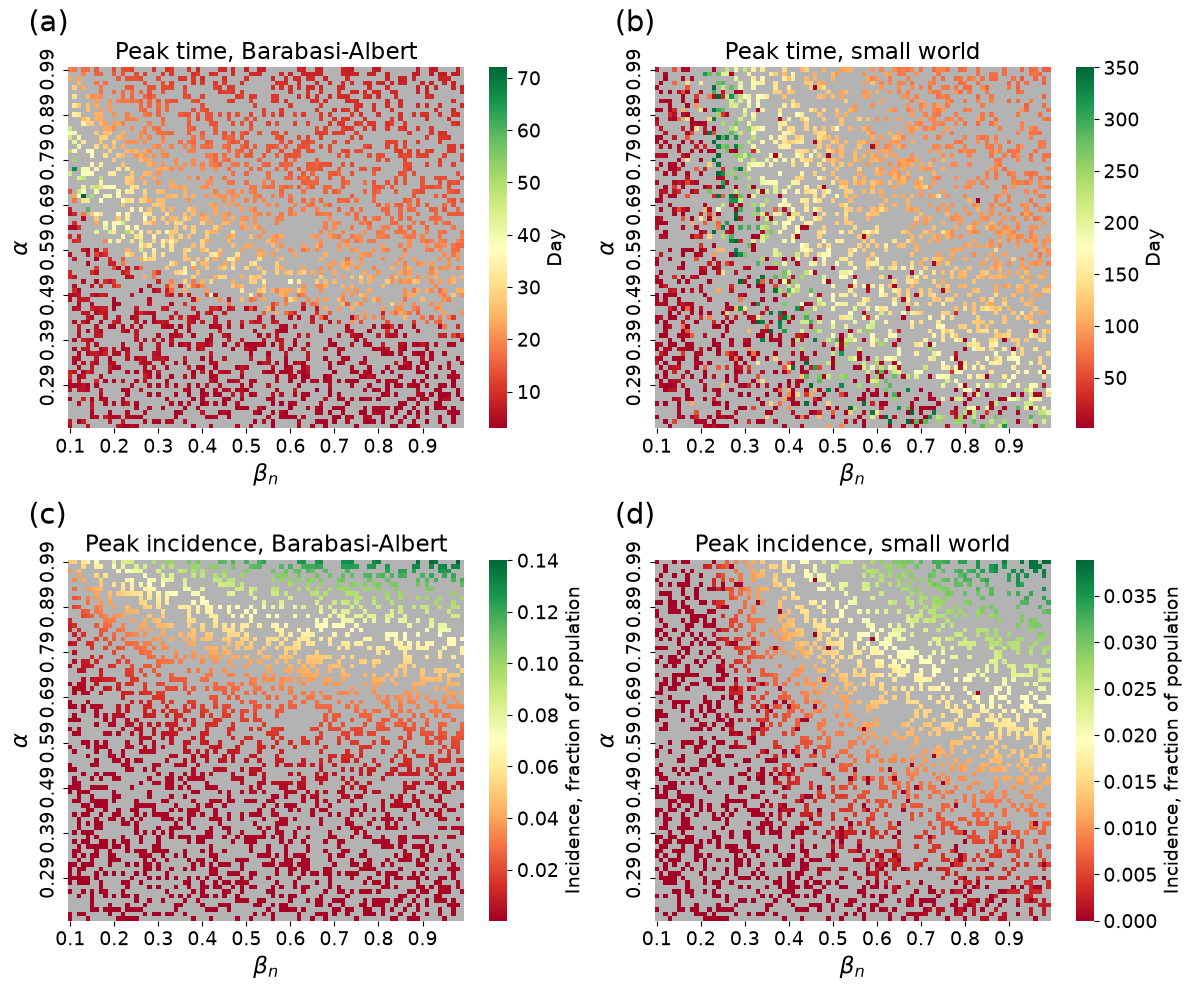

In [300]:
# PEAK INFECTED
fig, axes = plt.subplots(2,2, figsize=(12,10))
ax = axes.flatten()

heat_orig = aux_f.heatmap_orig_peaks(topology='ba',folder='hybrid_surr/aux_hyb/')
aux_f.peaks_hmaps(heat_orig, with_inc=True, title=', Barabasi-Albert', 
                  ax=[ax[0],ax[2]], n=['(a)','(c)'])
heat_orig = aux_f.heatmap_orig_peaks(topology='sw',folder='hybrid_surr/aux_hyb/')
aux_f.peaks_hmaps(heat_orig, with_inc=True, title=', small world', 
                  ax=[ax[1],ax[3]], n=['(b)','(d)'])

#plt.savefig(f'results/ba100_actual.pdf', format='pdf', bbox_inches='tight')

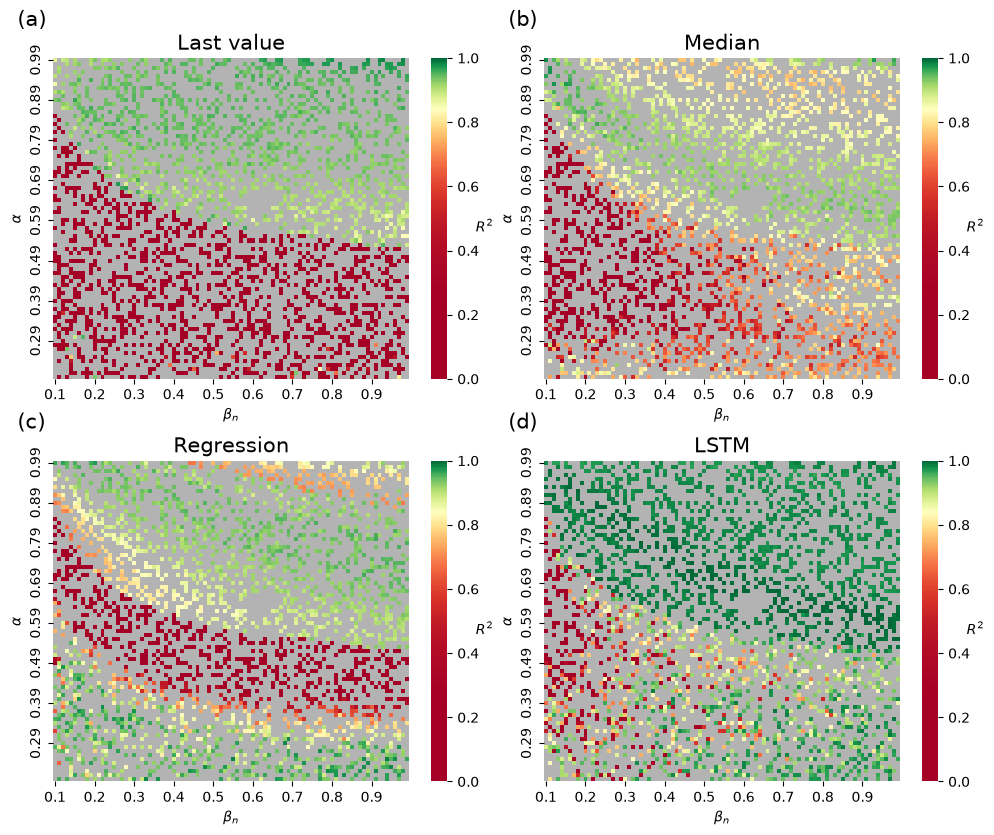

In [125]:
l=5
fin_inc = aux_f.df_metrics(folder_name='hybrid_surr/aux_hyb/',
                        top_name='new_ba_100000', 
                       test_suff='ba_', 
                       switch='fraq_people',
                       with_inc=True, 
                       trim=False, suff=f'_ba100k_sI_fullR_{l}')

aux_f.metric_hmaps(folder_name='hybrid_surr/aux_hyb/',
                   fin=fin_inc, met='r2_Inc', suff=f'_ba_sI_{l}', 
                   exclude=['Cumulative Average',
                            'Exponential Decay'],
                    save=False)


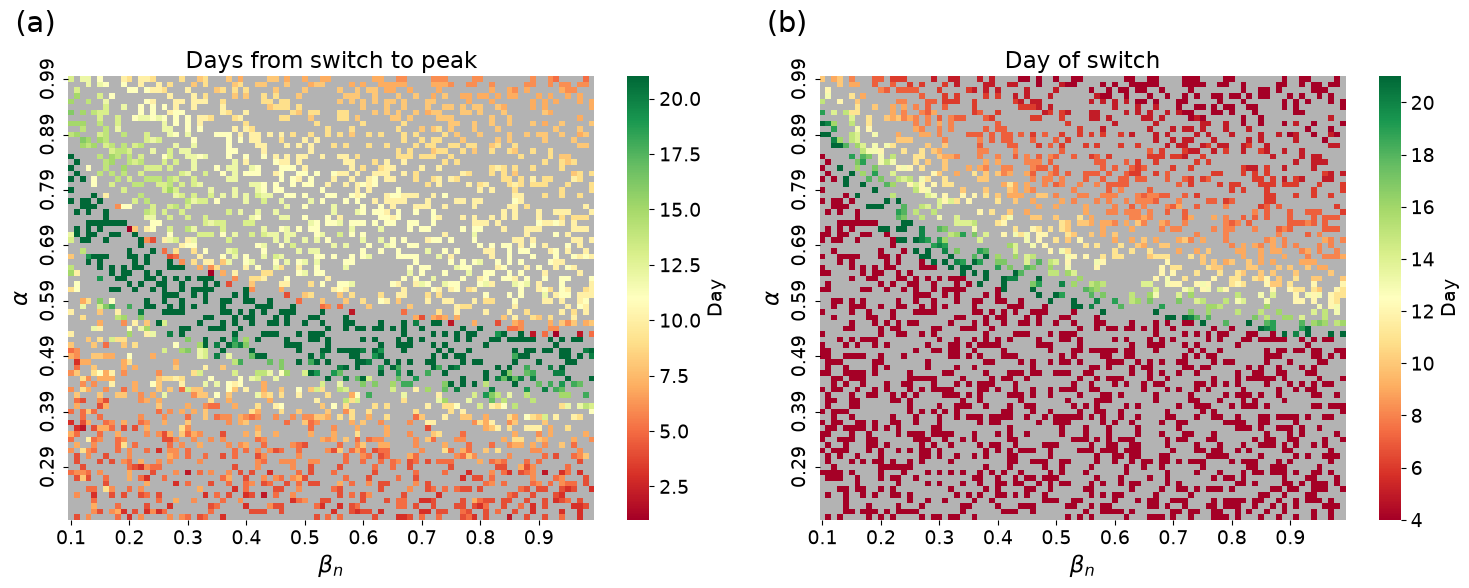

In [33]:
aux_f.smth_hmaps(fin_inc, 21)

In [107]:
sw = pd.read_csv('hybrid_surr/aux_hyb/sw_incidence_100k.csv')

In [109]:
from sklearn.model_selection import train_test_split

# 3:1:2
X_train, X_test = train_test_split(sw, test_size=int(sw.shape[0]*1/6), random_state=42)
#y = y.loc[X_train.index]
X_train, X_val = train_test_split(X_train, test_size=int(sw.shape[0]*2/6), random_state=42)
#X_train = X_train.sort_values(by = ['seed_number'])
#X_val = X_val.sort_values(by = ['seed_number'])
#X_test = X_test.sort_values(by = ['seed_number'])
len(X_train), len(X_val), len(X_test)

(3600, 2400, 1200)

In [ ]:

fig, axes = plt.subplots(2,2, figsize=(8,5))
ax = axes.flatten()

for i,file in enumerate(ba[::1]):
    df = pd.read_csv(dire_ba+file[0], usecols=['S','E','I','Beta'])
    temp = df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    
    l1 = ax[0].plot(df['incidence'], color='RoyalBlue', alpha=0.01)
    l2 = ax[2].plot(df.Beta, color='gray', alpha=0.005, marker='', ls='-')

ax[0].grid() 
ax[2].grid()

ax[0].axes.xaxis.set_ticklabels([])
ax[2].set_ylim(0,3e-5)

ax[0].set_ylabel('Incidence, cases')
ax[2].set_ylabel(r'$\beta_c$')
ax[2].set_xlabel('Time, days')

ax[0].set_xlim(0, 100)
ax[2].set_xlim(0, 100)


# ________________ sw
for i,file in enumerate(sw[::1]):
    df = pd.read_csv(dire+file[0], usecols=['S','E','I','Beta'])
    temp = df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    
    l1 = ax[1].plot(df['incidence'], color='RoyalBlue', alpha=0.01)
    l2 = ax[3].plot(df.Beta, color='gray', alpha=0.005, marker='', ls='-')

ax[1].grid() 
ax[3].grid()

ax[1].axes.xaxis.set_ticklabels([])
ax[3].set_ylim(0,5e-5)

ax[1].set_ylabel('Incidence, cases')
ax[3].set_ylabel(r'$\beta_c$')
ax[3].set_xlabel('Time, days')

ax[1].set_xlim(0, 100)
ax[3].set_xlim(0, 100)

n = ['a)','b)','c)','d)'][::-1]
for i in range(4):
    ax[i].text(-0.1, 1.1, n.pop(),
           transform=ax[i].transAxes, size=1.5*8)
        
plt.tight_layout()


In [ ]:
# PEAK INFECTED

fin = aux_f.df_metrics(folder_name='new_ba_100000', 
                       test_suff='', 
                       switch='fraq_people',
                       with_inc=True, 
                       trim=False, suff='_ba100k_sI_fullR_1')

aux_f.peaks_hmaps(fin, with_inc=True)

#plt.savefig(f'results/ba100_actual.pdf', format='pdf', bbox_inches='tight')

## hybrid

In [130]:
types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']
methods = ['last value','expanding mean last value',
            'median beta', 'regression beta', 'lstm' ]
new_labels = ['last_value', 'expanding_mean_last_value', 
            'median_beta',  'regression_beta', 'lstm_day_E_previous_I'
             ]

sigma=0.3
gamma=0.2
perc_switch=0.01
stoch=10

seed_dirs="../long_sw_100000_fin/"
#seed_dirs="../new_ba_100000/"
sw = pd.read_csv('hybrid_surr/aux_hyb/test_files.csv').values

In [318]:
%%time
df = pd.read_csv('hybrid_surr/aux_hyb/ba_incidence_100k.csv',
                skiprows=lambda x: x > 0 and (x - 1) % 10 != 0)
_,test_df = train_test_split(df, test_size=2400, 
                             random_state=42, stratify=None)
dfb = pd.read_csv('hybrid_surr/aux_hyb/ba_beta_100k.csv',
                 skiprows=lambda x: x > 0 and (x - 1) % 10 != 0)
_,test_dfb  = train_test_split(dfb, test_size=2400, 
                             random_state=42, stratify=None)
test_dfb

CPU times: total: 1.03 s
Wall time: 1.05 s


,beta,gamma,delta,init_inf_frac,alpha,0,1,2,3,4,...,140,141,142,143,144,145,146,147,148,149
3098,0.48,0.3,0.2,0.0001,0.78,0.001653,0.000063,0.000022,0.000015,0.000014,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2531,0.41,0.3,0.2,0.0001,0.71,0.001482,0.000081,0.000025,0.000016,0.000013,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
4071,0.60,0.3,0.2,0.0001,0.91,0.002335,0.000073,0.000039,0.000031,0.000025,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1287,0.26,0.3,0.2,0.0001,0.28,0.000779,0.000125,0.000036,0.000019,0.000009,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2540,0.41,0.3,0.2,0.0001,0.80,0.001635,0.000073,0.000026,0.000018,0.000015,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6865,0.95,0.3,0.2,0.0001,0.85,0.003210,0.000086,0.000041,0.000031,0.000027,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
6356,0.89,0.3,0.2,0.0001,0.56,0.002488,0.000071,0.000023,0.000016,0.000012,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
3378,0.52,0.3,0.2,0.0001,0.38,0.001453,0.000098,0.000026,0.000013,0.000009,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
4032,0.60,0.3,0.2,0.0001,0.52,0.001404,0.000066,0.000020,0.000014,0.000010,...,0.000004,0.000004,-0.0,0.000011,0.000004,0.000004,0.000007,-0.0,-0.0,0.0


In [322]:
test_df.iloc[200]

beta             0.7000
gamma            0.3000
delta            0.2000
init_inf_frac    0.0001
alpha            0.2400
                  ...  
145              0.0000
146              0.0000
147              0.0000
148              0.0000
149              0.0000
Name: 4803, Length: 155, dtype: float64

In [336]:
sw[::10][k:k+2]

array([['p_0.15999999999999998_0.3_0.2_0.0001_0.9000000000000006_seed_0.csv'],
       ['p_0.15999999999999998_0.3_0.2_0.0001_0.9300000000000006_seed_0.csv']],
      dtype=object)

path:  hybrid_surr/aux_hyb/ba100k_regression_bt.joblib
was there? 51
5 1000.0 fraq_people 0.01
was there? 46
5 1000.0 fraq_people 0.01
CPU times: total: 922 ms
Wall time: 917 ms


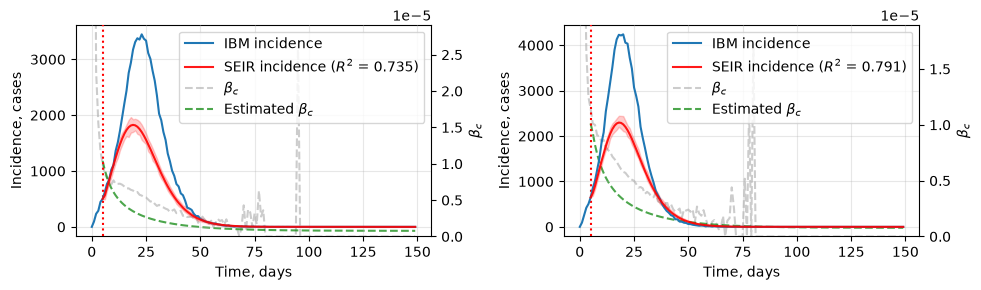

In [335]:
%%time
k = 200
sw = pd.read_csv('hybrid_surr/aux_hyb/ba_test_files.csv').values
plot_hyb.apply_methods(seed_dirs="../new_ba_100k/new_ba_100k/",
              seed_numbers=sw[::10][k:k+2], on_incidence=True,
              switch_on_incidence=False,
              idx_s=3, idx_e=4, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01, stoch=100, 
                m_folder='hybrid_surr/aux_hyb/',
             suff_m='ba100k', suff='ba100k_10')

In [342]:
[1,2,3].pop()

3

was there? 0
4 1000.0 fraq_people 0.01
was there? 0
4 1000.0 fraq_people 0.01
was there? 34
4 1000.0 fraq_people 0.01
was there? 34
4 1000.0 fraq_people 0.01


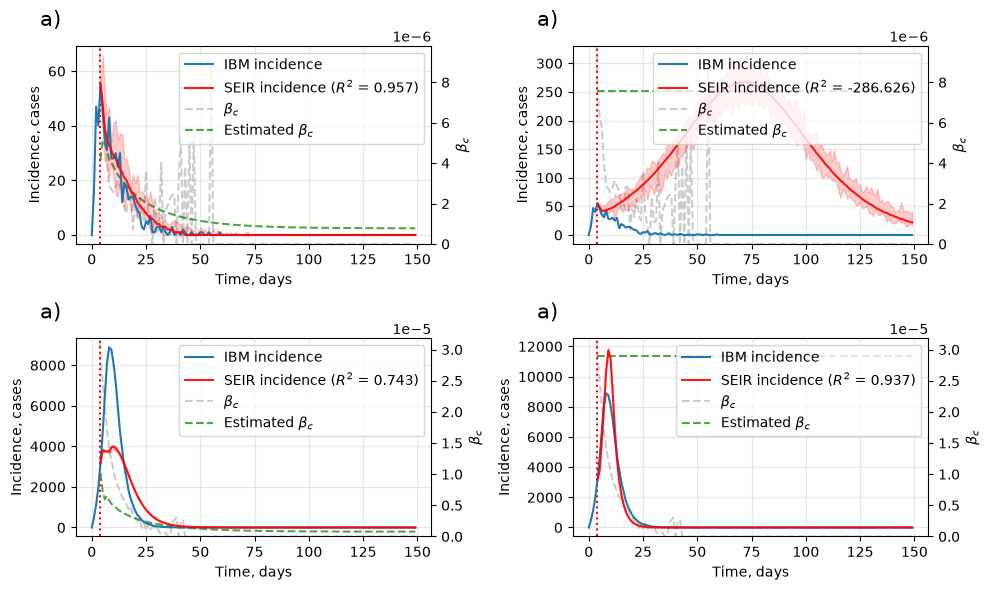

In [350]:
k = 145
fig, ax = plt.subplots(2,2, figsize=(10, 6))
ax = ax.flatten()
f = 'hybrid_surr/aux_hyb/'
types_start_day = ['fraq_people']
methods = ['last value','expanding mean last value',
               'median beta','regression beta', 'lstm']
seed_dirs = '../new_ba_100k/new_ba_100k/'
model_pathr = f+f'ba100k_regression_bt.joblib'
model_pathl = f+f'ba100k_lstm_4_001_s10'   

sigma=0.3
gamma=0.2
perc_switch=0.01
stoch=10
j=0
labs = ['(a)','(a)','c','d']
for k in [145,2320]:
    for method in ['regression beta', 'last value']:
        plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=stoch, 
                        beta_prediction_method=method, 
                        type_start_day=types_start_day[0], 
                        seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                        seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                        ax=[ax[j]], 
                        model_path=model_pathr,perc_switch=perc_switch,
                        is_filename=True,on_incidence=True,
                        switch_on_incidence=False)
        ax[j].text(-0.1, 1.1, labs.pop(),
                   transform=ax[j].transAxes, size=15)
        j+=1
        

plt.tight_layout()

### synthetic incidence and betas

In [297]:
mtest_ba, mtest_ba_beta = aux_f.get_synth_inc_beta(topology='ba', folder='hybrid_surr/aux_hyb')
mtest_sw, mtest_sw_beta = aux_f.get_synth_inc_beta(topology='sw', folder='hybrid_surr/aux_hyb')

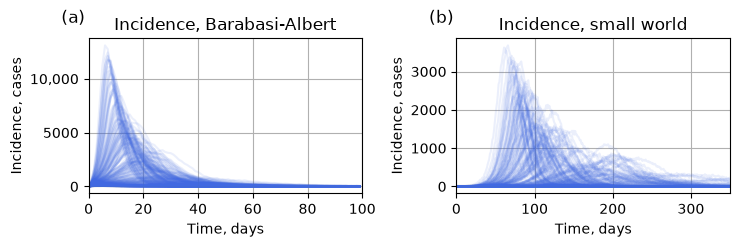

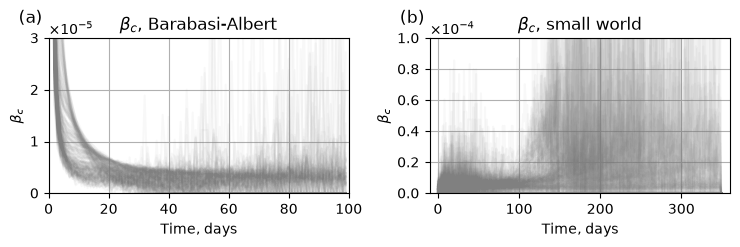

In [298]:
from matplotlib.ticker import FormatStrFormatter,ScalarFormatter,FuncFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

# 1. Функция автоматического форматирования
def comma_format(x, pos):
    if x >= 10000:
        return f"{int(x):,}" # Добавляет запятую как разделитель тысяч
    return f"{int(x)}"       # Оставляет число как есть (например, 1000)
        
fig, axes = plt.subplots(1,2, figsize=(7.5,2.5))
ax = axes.flatten()

fig2, axes2 = plt.subplots(1,2, figsize=(7.5,2.5))
ax2 = axes2.flatten()

for mtest, mtest_beta, i, tmax, label in zip([mtest_ba, mtest_sw],
                                      [mtest_ba_beta, mtest_sw_beta],
                                           range(2), [100,350], 
                                             ['Barabasi-Albert','small world']):
    l1 = ax[i].plot(np.arange(tmax), mtest.iloc[::10,:tmax].T, 
                    color='RoyalBlue', alpha=0.1)
    l2 = ax2[i].plot(np.arange(tmax), mtest_beta.iloc[::10,:tmax].T, 
                     color='gray', alpha=0.05, marker='', ls='-')
    
    ax[i].grid() 
    ax2[i].grid()
    
    #ax[i].axes.xaxis.set_ticklabels([])
    if 'Albert' in label:
        ax2[i].set_ylim(0,3e-5)
        ax[i].set_xlim(0, tmax)
        ax2[i].set_xlim(0, tmax)
    else:
        ax2[i].set_ylim(0,1e-4)
        ax[i].set_xlim(0, tmax)
        ax2[i].set_xlim(-10, tmax+10)

    ax[i].set_title(f'Incidence, {label}')
    ax[i].set_ylabel('Incidence, cases')
    ax[i].set_xlabel('Time, days')
    #ax[i].yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
    ax[i].yaxis.set_major_formatter(FuncFormatter(comma_format))
    
    ax2[i].set_title(fr'$\beta_c$, {label}')
    ax2[i].set_ylabel(r'$\beta_c$')
    ax2[i].set_xlabel('Time, days')

    
    #ax2[i].set_yscale('linear')
    #ax2[i].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax2[i].yaxis.set_major_formatter(formatter)
    

fig.tight_layout()
fig2.tight_layout()

n = ['(a)','(b)','(a)','(b)'][::-1]
for ax_i in [ax,ax2]:
    for i in range(2):
        ax_i[i].text(-0.1, 1.1, n.pop(),
               transform=ax_i[i].transAxes, size=1.5*8)
        


#plt.savefig(f'results/ba_sw.pdf', format='pdf', bbox_inches='tight')
#plt.savefig(f'results/ba_sw.png', format='png', bbox_inches='tight')

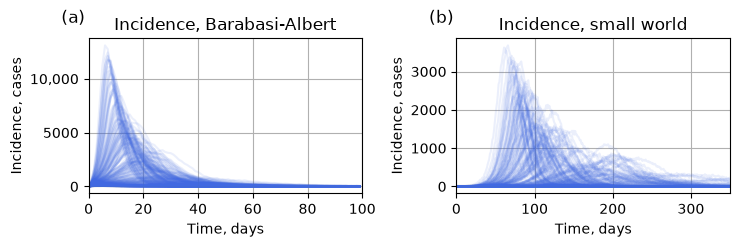

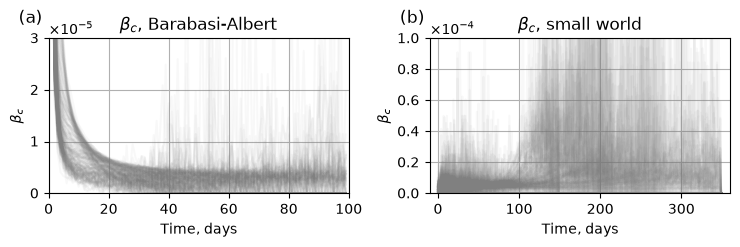

In [204]:
aux_f.plot_synth_inc_beta(folder='hybrid_surr/aux_hyb/')

FileNotFoundError: [Errno 2] No such file or directory: '../new_ba_100000/p_0.14999999999999997_0.3_0.2_0.0001_0.38000000000000017_seed_0.csv'

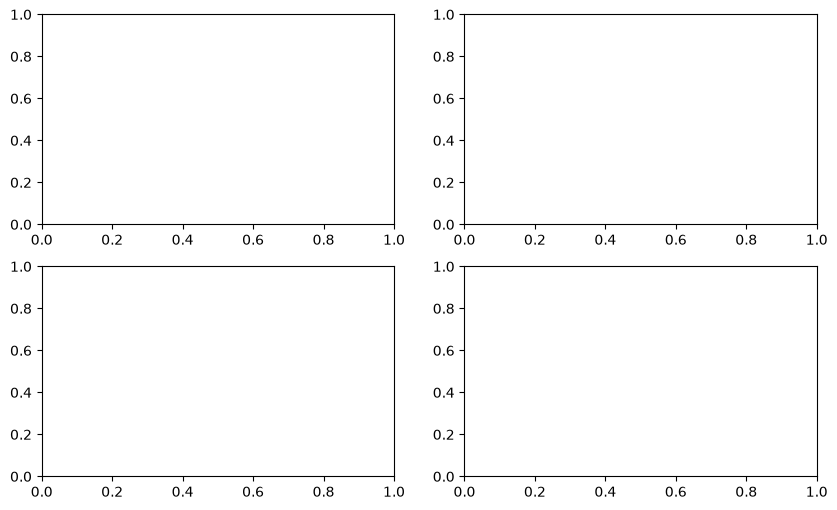

In [136]:
fig, ax = plt.subplots(2,2, figsize=(10, 6))
ax = ax.flatten()

model_pathr = f'hybrid_surr/aux_hyb/ba100k_regression_bt.joblib'
model_pathl = f'hybrid_surr/aux_hyb/ba100k_lstm_4_001_s10' 
types_start_day = 'fraq_people'
count_stoch_line=10
seed_dirs="../new_ba_100000/"
sw = pd.read_csv('hybrid_surr/aux_hyb/ba_test_files.csv').values

k = 145
plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=count_stoch_line, 
                beta_prediction_method=methods[-2], 
                type_start_day=types_start_day, 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[0]], model_path=model_pathr,perc_switch=perc_switch,
                is_filename=True,on_incidence=True,switch_on_incidence=False)
ax[0].text(-0.1, 1.1, '(a)',
           transform=ax[0].transAxes, size=15)

plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=count_stoch_line, 
                beta_prediction_method=methods[-1], 
                type_start_day=types_start_day, 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[1]], model_path=model_pathl,perc_switch=perc_switch,
                is_filename=True,on_incidence=True,switch_on_incidence=False);
ax[1].text(-0.1, 1.1, '(b)',
           transform=ax[1].transAxes, size=15)
k = 2320
plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=count_stoch_line, 
                beta_prediction_method=methods[-2], 
                type_start_day=types_start_day, 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[2]], model_path=model_pathr,perc_switch=perc_switch,
                is_filename=True,on_incidence=True,switch_on_incidence=False)
ax[2].text(-0.1, 1.1, '(c)',
           transform=ax[2].transAxes, size=15)

plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=count_stoch_line, 
                beta_prediction_method=methods[-1], 
                type_start_day=types_start_day, 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[3]], model_path=model_pathl,perc_switch=perc_switch,
                is_filename=True,on_incidence=True,switch_on_incidence=False);
ax[3].text(-0.1, 1.1, '(d)',
           transform=ax[3].transAxes, size=15)

plt.tight_layout()
#plt.savefig(f'results/regr_lstm.pdf', format='pdf', bbox_inches='tight')

was there? 0
4 1000.0 fraq_people 0.01


PermissionError: [Errno 13] Permission denied: 'hybrid_surr/aux_hyb/'

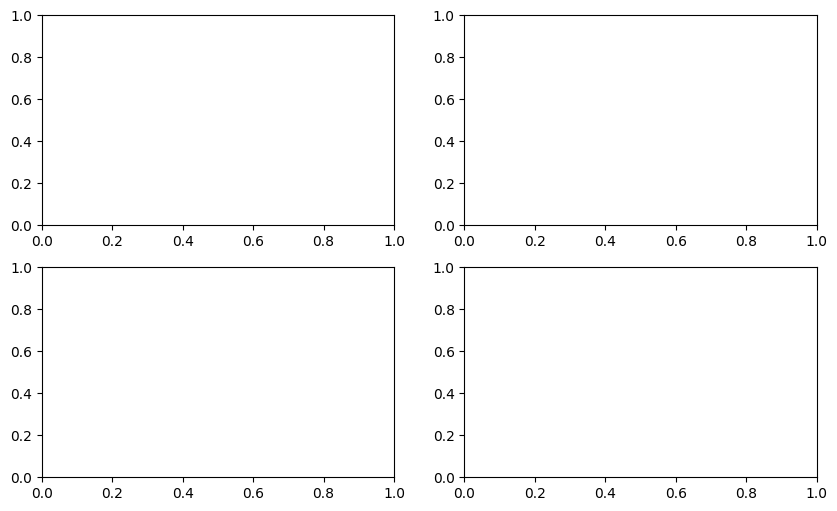

In [49]:
types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']
methods = ['last value','expanding mean last value',
           'median beta','regression beta', 'lstm']
new_labels = ['last_value', 'expanding_mean_last_value', 
            'median_beta', 'regression_beta', 
              'lstm_day_E_previous_I']
suff_m='sw100k'
suff='sw100k'
topology =suff_m[:2] 
beta_pred = 'median'
m_folder='hybrid_surr/aux_hyb/'

if 'median' in beta_pred:
    model_path = f'{m_folder}{suff_m}_median_beta.csv'
elif 'regression beta' in beta_pred:
    model_path = f'{m_folder}{suff_m}_regression_bt.joblib'
elif 'lstm' in beta_pred:
    model_path = f'{m_folder}{suff_m}_lstm_4_001_s10'   
else:
    model_path=''
                
k = 145
fig, ax = plt.subplots(2,2, figsize=(10, 6))
ax = ax.flatten()

plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=100, 
                beta_prediction_method=methods[-2], 
                type_start_day=types_start_day[0], 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[0]], model_path='hybrid_surr/aux_hyb/',
                perc_switch=perc_switch,
                is_filename=True,on_incidence=True,
                switch_on_incidence=False)
ax[0].text(-0.1, 1.1, 'a)',
           transform=ax[0].transAxes, size=15)

plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=100, 
                beta_prediction_method=methods[-1], 
                type_start_day=types_start_day[0], 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[1]], model_path='hybrid_surr/aux_hyb/',
                perc_switch=perc_switch,
                is_filename=True,on_incidence=True,
                switch_on_incidence=False)
ax[1].text(-0.1, 1.1, 'b)',
           transform=ax[1].transAxes, size=15)


plt.tight_layout()

## surrogate

In [25]:
folder = 'hybrid_surr/calibr/'
folder

'hybrid_surr/calibr/'

In [30]:
# Loading
ae = torch.load(folder+'/models/autoencoder_ba_100k_n.pt', weights_only=False)

X_train, y_train, X_test, y_test, tmax = surr_funcs.get_splits_df(folder=folder, 
                                                            type_df='point',
                                                            network_type = 'ba')

([0.9061567187309265,
  0.9836651682853699,
  0.9941647052764893,
  0.9818785786628723],
 [array([0.35, 0.44]),
  array([0.4 , 0.59]),
  array([0.41, 0.71]),
  array([0.37, 0.75])])

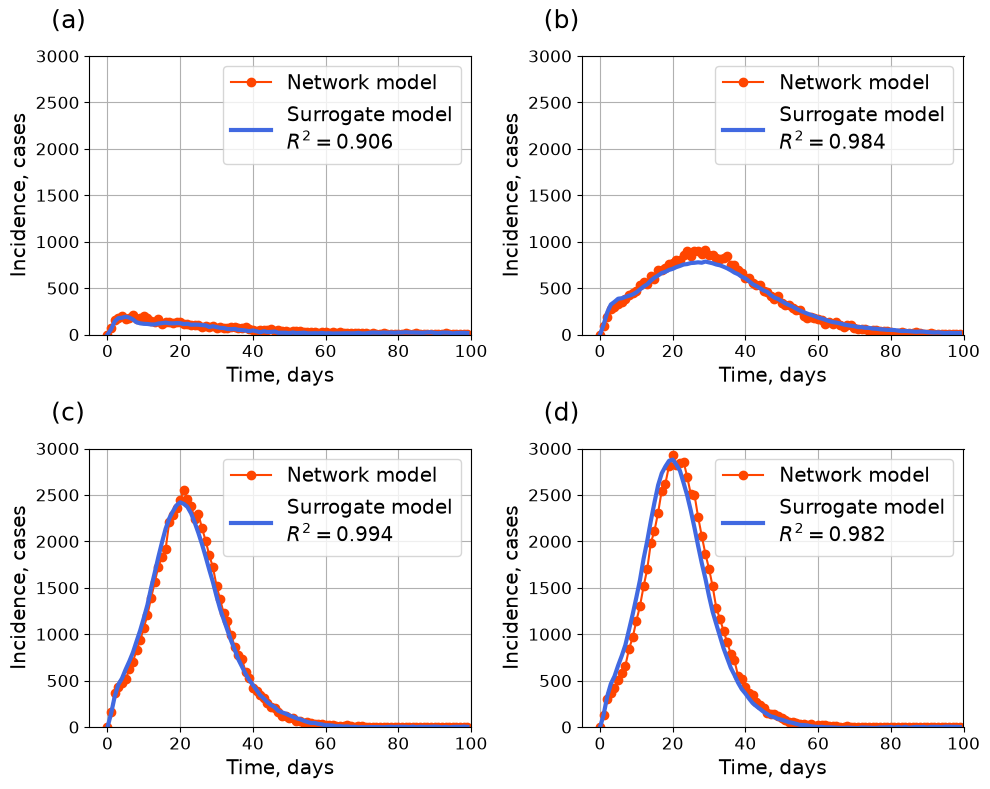

In [33]:
fontsize = 12
test_indices = [11,7,1,15]
rows = 2
cols = 2
fig, ax = plt.subplots(rows, cols, figsize=(10, 8))

labels = ['(a)', '(b)', '(c)', '(d)']
counter = 0
cut = 100
rs = []
abs = []
for row in range(rows):
    for col in range(cols):
        surrogate_sim = surr_funcs.predict(ae, X_test[test_indices[counter]]).numpy()
        r2 = r2_score(y_test[test_indices[counter]], surrogate_sim)
        #print(labels[counter], test_indices[counter], X_test[test_indices[counter]])
        rs.append(r2)
        abs.append(X_test[test_indices[counter]])
        ax[row][col].plot(y_test[test_indices[counter]][:cut], 
                          label='Network model', marker='o', color='OrangeRed')
        ax[row][col].plot(surrogate_sim[:cut], lw=3, color='RoyalBlue', 
                          label=f'Surrogate model\n$R^2=${r2:.3f}')

        ax[row][col].set_xlabel('Time, days', fontsize=1.2*fontsize)
        ax[row][col].set_ylabel('Incidence, cases', fontsize=1.2*fontsize)
        ax[row][col].set_ylim(0, 3000)
        ax[row][col].set_xlim(-5, 100)
        ax[row][col].tick_params(axis='both', which='major', labelsize=fontsize)
        ax[row][col].legend(fontsize=1.2*fontsize)
        ax[row][col].grid()
        
        # Add subplot label outside the top-left corner
        ax[row][col].text(-0.1, 1.1, labels[counter],
                    transform=ax[row][col].transAxes, size=fontsize*1.5)
        counter += 1

plt.tight_layout()
#fig.savefig(r'ae_{}_network_subplots_point_estimation_n.pdf'.format(network_type), 
#            bbox_inches='tight')
#fig.savefig(r'ae_{}_network_subplots_point_estimation_n.png'.format(network_type), 
#            dpi=150, bbox_inches='tight')
rs, abs

In [206]:
folder

'hybrid_surr/calibr/'

In [208]:
# Loading
from sklearn.model_selection import train_test_split
ae = torch.load(folder+'/models/autoencoder_interval_ba_100k_n.pt', weights_only=False)

X_train, y_train, X_test, y_test, tmax, mtest,qw = \
                        surr_funcs.get_splits_df(folder=folder, 
                                                 folder_all='hybrid_surr/aux_hyb/',
                                                  type_df='interval',network_type = 'ba',
                                                  with_orig_X=True)


In [215]:
qw

,gamma,delta,init_inf_frac,alpha,0,1,2,3,4,5,...,141,142,143,144,145,146,147,148,149,group
0,0.3,0.2,0.0001,0.21,0.0,14.0,23.0,32.0,48.0,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.3,0.2,0.0001,0.22,0.0,11.0,29.0,33.0,28.0,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.3,0.2,0.0001,0.23,0.0,9.0,33.0,39.0,35.0,39.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.3,0.2,0.0001,0.24,0.0,13.0,37.0,33.0,40.0,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.3,0.2,0.0001,0.25,0.0,10.0,28.0,37.0,47.0,28.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,0.3,0.2,0.0001,0.95,0.0,565.0,1451.0,2852.0,5217.0,8337.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,719
7196,0.3,0.2,0.0001,0.96,0.0,643.0,1808.0,3580.0,6547.0,9777.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,719
7197,0.3,0.2,0.0001,0.97,0.0,612.0,1707.0,3589.0,6842.0,10221.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,719
7198,0.3,0.2,0.0001,0.98,0.0,697.0,2183.0,4896.0,8930.0,12058.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,719


In [214]:
mtest

,beta,alpha
3098,0.48,0.78
2531,0.41,0.71
4071,0.60,0.91
1287,0.26,0.27
2540,0.41,0.80
...,...,...
6865,0.95,0.85
6356,0.89,0.56
3378,0.52,0.38
4032,0.60,0.52


([0.9496718645095825,
  0.9777136445045471,
  0.9948103427886963,
  0.9943745732307434],
 [array([0.84, 0.29]),
  array([0.4 , 0.59]),
  array([0.41, 0.71]),
  array([0.66, 0.6 ])])

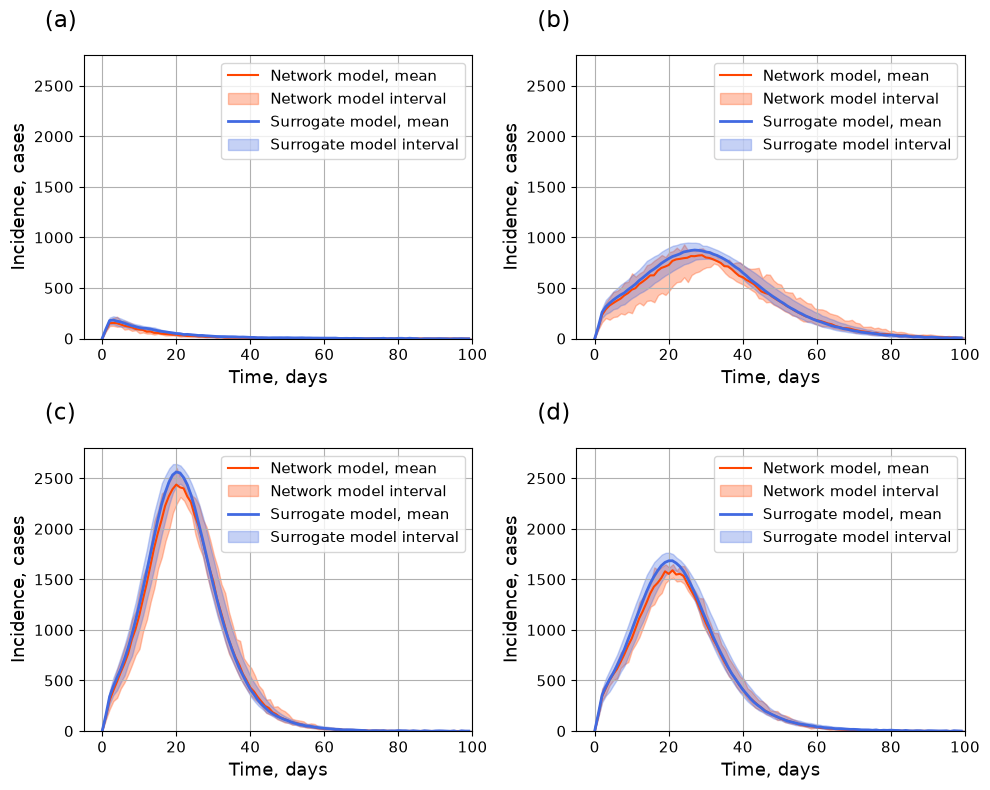

In [209]:
fontsize = 11
test_indices = [1100,7,1,150]
                
rows = 2
cols = 2
fig, ax = plt.subplots(rows, cols, figsize=(10, 8))

labels = ['(a)', '(b)', '(c)', '(d)']
counter = 0
mean_index = range(tmax)
low_index = range(tmax, 2*tmax)
high_index = range(2*tmax, 3*tmax)
cut = 100
rs = []
abs = []
for row in range(rows):
    for col in range(cols):
        surrogate_sim = surr_funcs.predict(ae, X_test[test_indices[counter]]).numpy()
        r2 = r2_score(y_test[test_indices[counter]], surrogate_sim)
        rs.append(r2)
        abs.append(X_test[test_indices[counter]])
        gt = np.array(y_test[test_indices[counter]])
        
        ax[row][col].plot(gt[mean_index][:cut], label='Network model, mean', 
                          marker='', color='OrangeRed')
        
        real_idx = mtest.iloc[test_indices[counter]].name
        part = qw[qw.group==real_idx].iloc[:,5:-1]
        part.columns = part.columns.astype(int)
        ax[row][col].plot(part.T, color='OrangeRed', ls=':', alpha=.5,
                         label=['Network model, trajectory']+['']*9)
    
        ax[row][col].fill_between(np.linspace(0, tmax, tmax)[:cut], 
                                  gt[low_index][:cut], gt[high_index][:cut],
                            alpha = 0.3, color='OrangeRed', 
                                  label='Network model interval')
        
        ax[row][col].plot(surrogate_sim[mean_index][:cut], lw=2, 
                          color='RoyalBlue', label='Surrogate model, mean')
        ax[row][col].fill_between(np.linspace(0, tmax, tmax)[:cut], 
                    surrogate_sim[low_index][:cut], 
                    surrogate_sim[high_index][:cut],
                    alpha = 0.3, color='RoyalBlue', 
                                  label='Surrogate model interval')

        ax[row][col].set_xlabel('Time, days', fontsize=1.2*fontsize)
        ax[row][col].set_ylabel('Incidence, cases', fontsize=1.2*fontsize)
        ax[row][col].set_ylim(0, 2800)
        ax[row][col].set_xlim(-5, cut)
        ax[row][col].tick_params(axis='both', which='major', labelsize=fontsize)
        ax[row][col].legend(fontsize=fontsize)
        ax[row][col].grid()
        
        # Add subplot label outside the top-left corner
        ax[row][col].text(-0.1, 1.1, labels[counter],
                    transform=ax[row][col].transAxes, size=fontsize*1.5)
        
        counter += 1

plt.tight_layout()
'''
fig.savefig('../figures/ae_ba_network_subplots_interval_estimation.pdf', bbox_inches='tight')
fig.savefig('../figures/ae_ba_network_subplots_interval_estimation.png', dpi=150, bbox_inches='tight')
'''
rs, abs

In [36]:
type_df = 'point'
ae = torch.load(folder+'/models/autoencoder_ba_100k_n.pt', weights_only=False)
X_train, y_train, X_test, y_test,tmax = surr_funcs.get_splits_df(folder=folder, 
                                                            type_df=type_df,
                                                            network_type = 'ba')
dd = surr_funcs.df_for_heatmap(ae, type_df,X_train, y_train, 
                               X_test, y_test, tmax)

type_df = 'interval'
ae = torch.load(folder+'/models/autoencoder_interval_ba_100k_n.pt', weights_only=False)
X_train, y_train, X_test, y_test,tmax = surr_funcs.get_splits_df(folder=folder, 
                                                            type_df=type_df,
                                                            network_type = 'ba')
dd2_mean,dd2_min,dd2_high = surr_funcs.df_for_heatmap(ae, type_df,X_train, y_train, 
                                                      X_test, y_test, tmax)

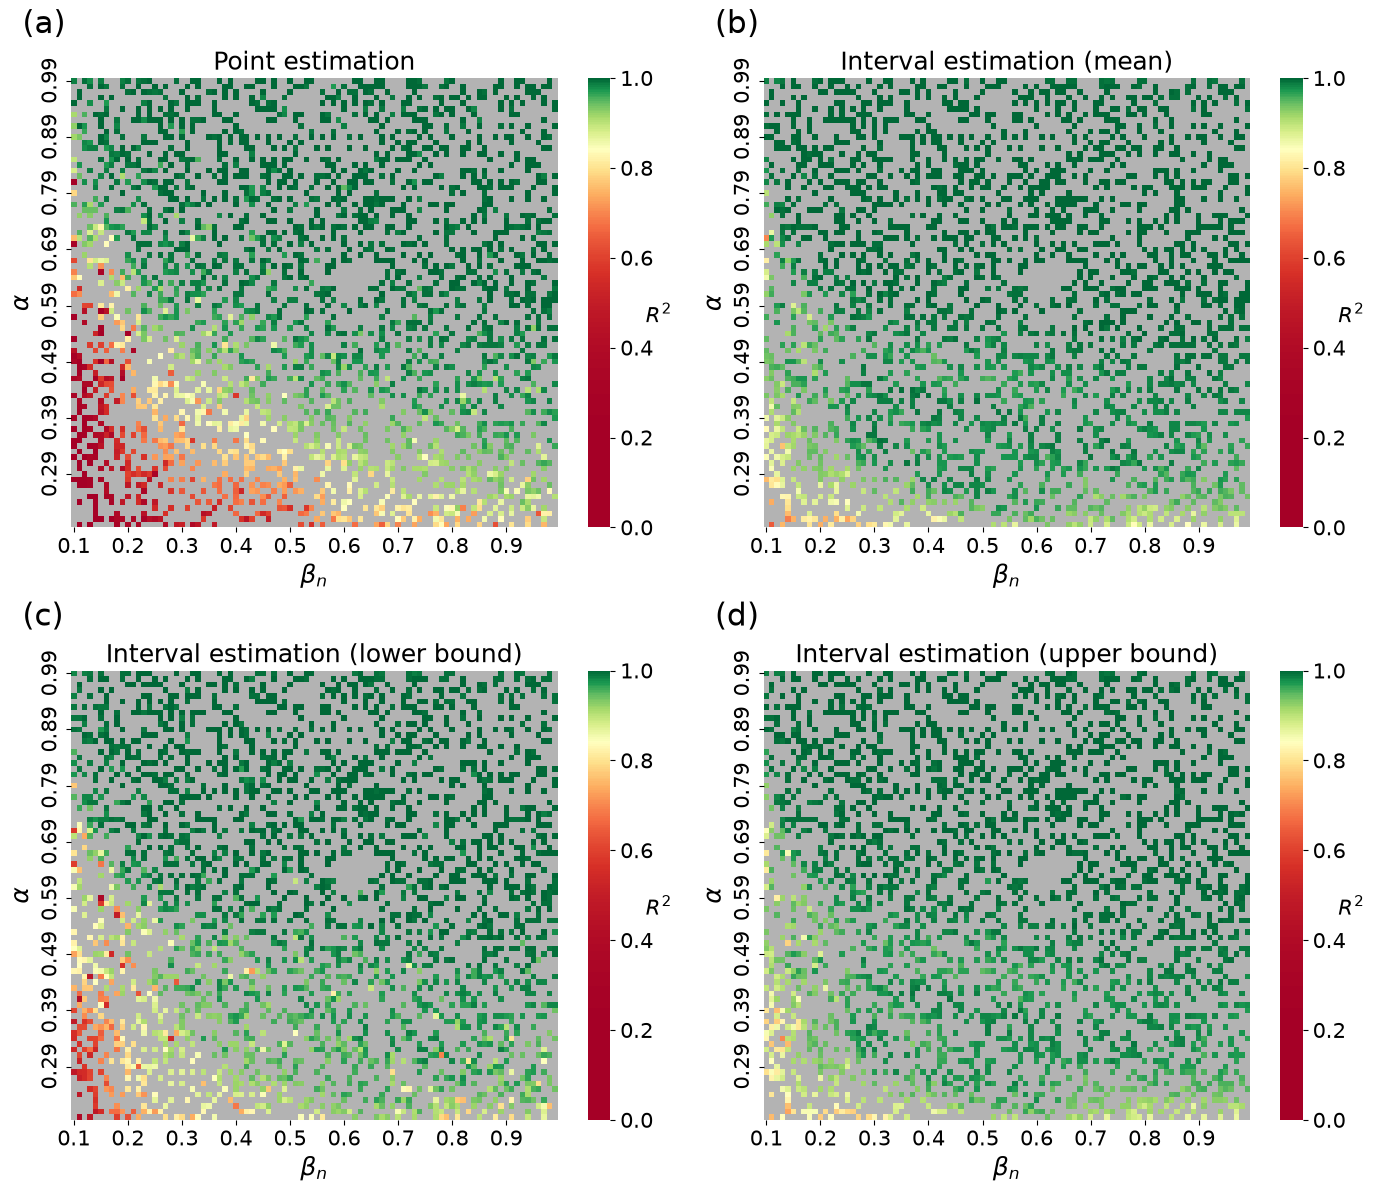

In [37]:
import seaborn as sns

fontsize = 15
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax=axes.flatten()

n = ['(a)','(b)','(c)','(d)'][::-1]

cmap = surr_funcs.nonlinear_cmap()
for i,heat_df, title in zip(range(4), 
                            [dd,dd2_mean,dd2_min,dd2_high], 
                            ['Point estimation','Interval estimation (mean)',
                            'Interval estimation (lower bound)',
                            'Interval estimation (upper bound)'
                            ]):
    
    ax_i = sns.heatmap(heat_df.sort_index(level=1, ascending=False), 
                       cmap=cmap, ax=ax[i], #norm=norm, 
                       cbar_kws={'extendfrac': .1,
                                #"ticks":ticks, "boundaries":boundaries
                                },
                       vmin=0, vmax=1,
                      xticklabels = 10, yticklabels=10,
                      linewidths=0.0, rasterized=True,)
    ax_i.set_title(title, fontsize=1.2*fontsize)
    ax_i.text(-0.1, 1.1, n.pop(),
              transform=ax_i.transAxes, size=1.5*fontsize)
    ax_i.collections[0].cmap.set_bad('0.7')
    ax_i.set_xlabel(r'$\beta_n$', fontsize=1.2*fontsize)
    ax_i.set_ylabel(r'$\alpha$', fontsize=1.2*fontsize)
    ax_i.tick_params(axis='both', which='major', labelsize=fontsize)
    cbar = ax_i.collections[0].colorbar
    cbar.set_label(r'$R^2$', rotation=0, size=fontsize)
        
for i in [-1,-2,-3,-4]:    
    ax_i.figure.axes[i].tick_params(labelsize=fontsize)

#ax_1.figure.axes[-1].set_ylabel(r'$R^2$', size=fontsize)
#ax_1.figure.axes[-2].set_ylabel(r'$R^2$', size=fontsize)

plt.tight_layout()
#fig.savefig(r'../figures/ae_colormap_n.png', dpi=150, bbox_inches='tight')
#fig.savefig(r'../figures/ae_colormap_n.pdf',  bbox_inches='tight')

## calibrating

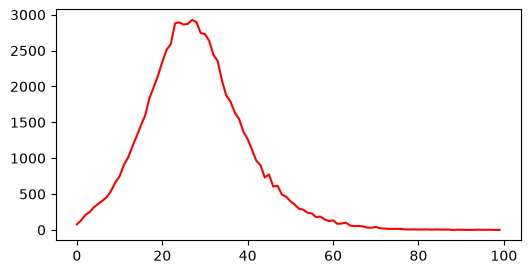

In [128]:

'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
folder='hybrid_surr/calibr/'

file=folder+'data_ba_100000.csv'
d = pd.read_csv(file, index_col=0)#.iloc[::10]
if 'init_rec_frac' in d.columns:
    d.rename(columns={'init_rec_frac':'alpha'}, inplace=True)
d.drop(columns=['gamma','delta','init_inf_frac'], inplace=True)
s = 150

plt.subplots(figsize=(6,3))

observed_data = pd.read_csv(folder+f'observed_incidence_a{true_alpha}_b{true_tau}.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)\
plt.plot(observed_data,color='red')

### one calibr plot

0.149405969205227 0.8945333434284561
sim plot time 0.27143073081970215
[1]
CPU times: total: 4.58 s
Wall time: 4.74 s


(0.149405969205227, 0.8945333434284561)

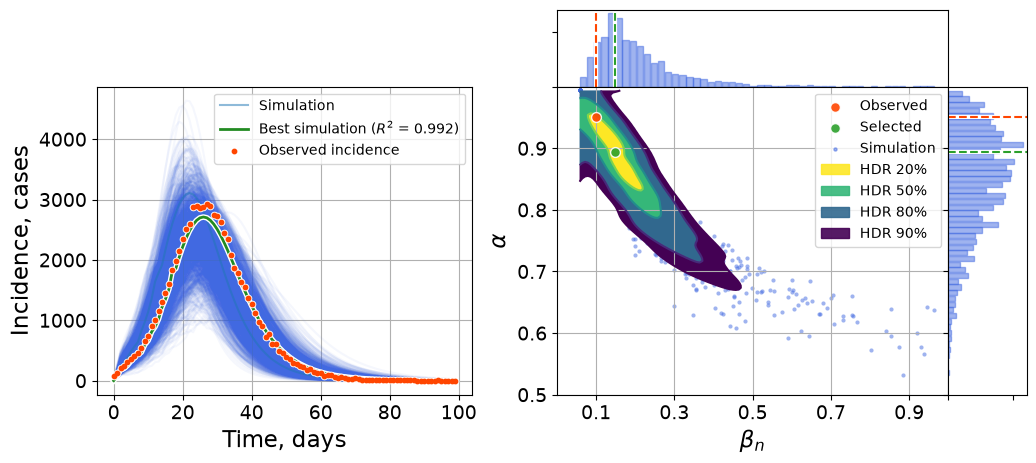

In [38]:
%%time
with_switch=np.array(True) 
with_df=np.array(False) 
num_runs=[1]
frac=[0.05]
gamma = 0.3
delta=0.2
n_nodes=100000

#draws = 600
#chains = 3
top='ba'
koeff=1
shift=0
network_params=[with_switch,num_runs,frac,gamma,
                delta,n_nodes,top,koeff,shift]

idata = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1.nc")
plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params,
                     n_hyb_runs=1)
#plt.savefig(f'results/ba_hybrid.pdf', format='pdf', bbox_inches='tight')
#png.getvalue()

### 3 in 1 calibr plots

0.1615659924746181 0.8760162288835825
sim plot time 0.93941330909729
[1]
0.149405969205227 0.8945333434284561
sim plot time 0.34210753440856934
[1]
0.1512882948042508 0.8855652941232481
sim plot time 3.3020801544189453
[0]
CPU times: total: 2min 28s
Wall time: 2min 29s


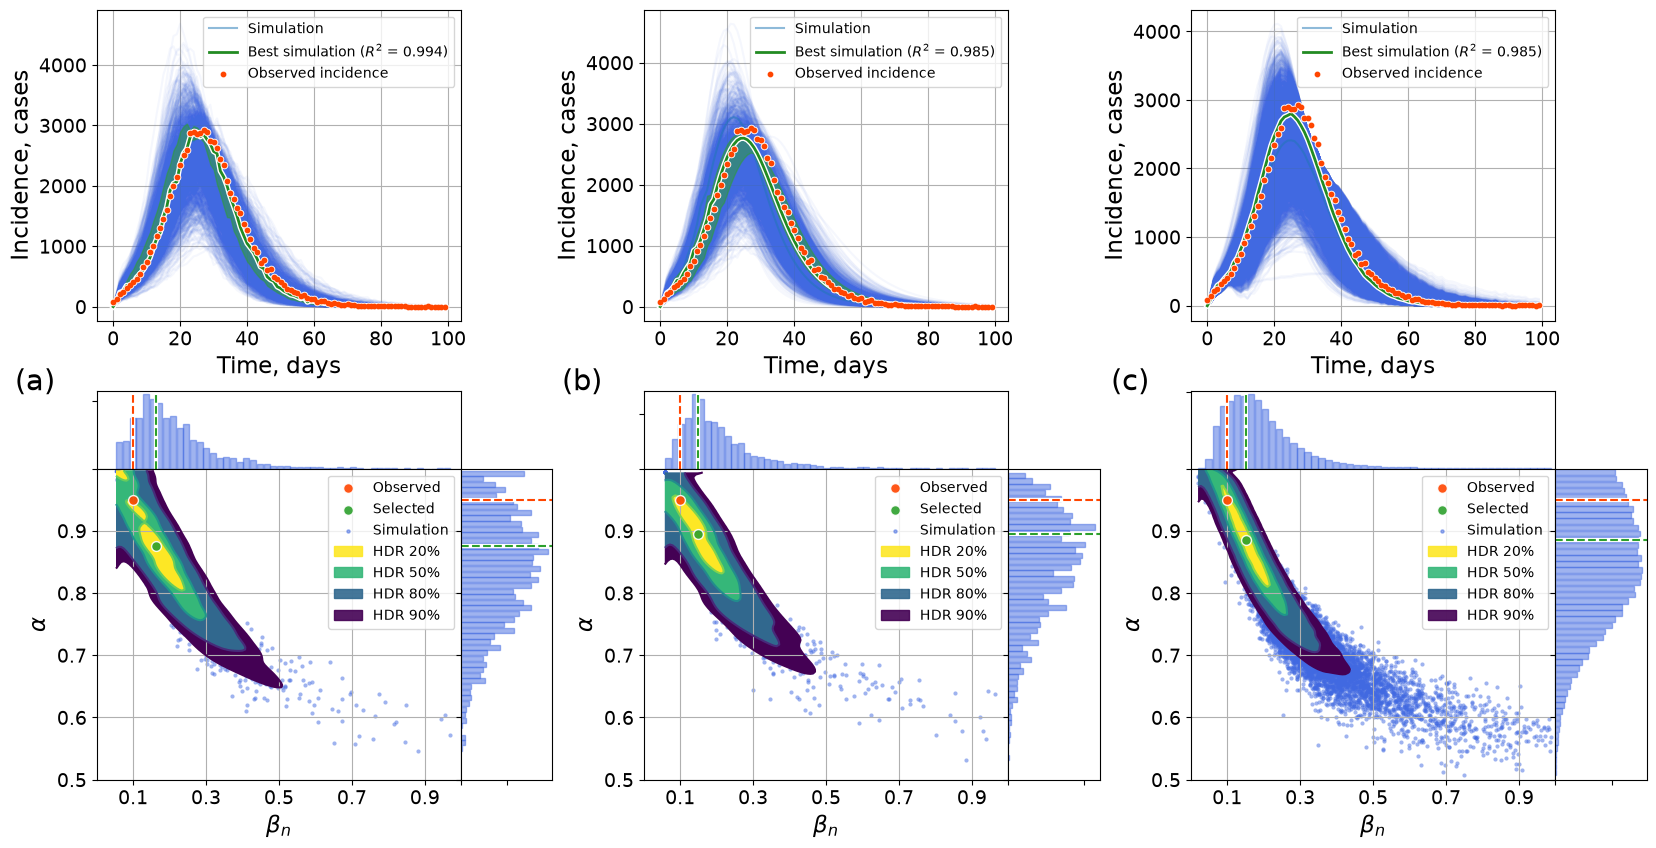

In [6]:
%%time
alphabet = 'abcdefghijklmnopqrstuvwxyz'
labels = ['('+alphabet[index] + ')' for index in range(len(alphabet))]

fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
top='ba'
idata14 = az.from_netcdf(folder+f"ba_net_a0.95_b0.1.nc")
idata7 = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1.nc")
idata0 = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1.nc").rename({"beta": "tau"})


with_switch=np.array(False) 
n_hyb_runs=10
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000
network_params=[with_switch,num_runs,frac,
                gamma,delta,n_nodes,top,koeff,shift]


for gs_0i, gs_1i, idata_i,idx  in zip([gs00,gs01,gs02],
                                 [gs10,gs11,gs12],
                         [idata14,idata7,idata0],
                                     np.arange(3)):
    
    if idx==1:
        frac=[0.05]
        with_switch=np.array(True) 
        network_params=[with_switch,num_runs,frac,gamma,
                        delta,n_nodes,top,koeff,shift]
    elif idx == 2:
        num_runs = [0]
        frac=[1]
        with_switch=np.array(False) 
        network_params=[with_switch,num_runs,frac,gamma,
                        delta,n_nodes,top,koeff,shift]

    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    beta_mode, alpha_mode = plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=False,
                          n_hyb_runs=n_hyb_runs,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])
    fontsize=14
    ax_curves.annotate(labels[idx], xy=(0, 0), xycoords='axes fraction',
                           xytext=(-30, -50), textcoords='offset points',
                           fontsize=1.5*fontsize, ha='right', va='baseline')
    
#plt.savefig(f'results/ba_all_appr.pdf', bbox_inches='tight')
#plt.savefig(f'results/ba_all_appr.png', bbox_inches='tight')

### 3in1 forecast calibr HYBRID plot

0.3319899334904737 0.7018917114413784
sim plot time 0.38265228271484375
[1]
0.3124724971578574 0.7423251112435076
sim plot time 0.25195932388305664
[1]
0.09926934980124971 0.9556286086094852
sim plot time 0.23173832893371582
[1]
CPU times: total: 4.97 s
Wall time: 5.02 s


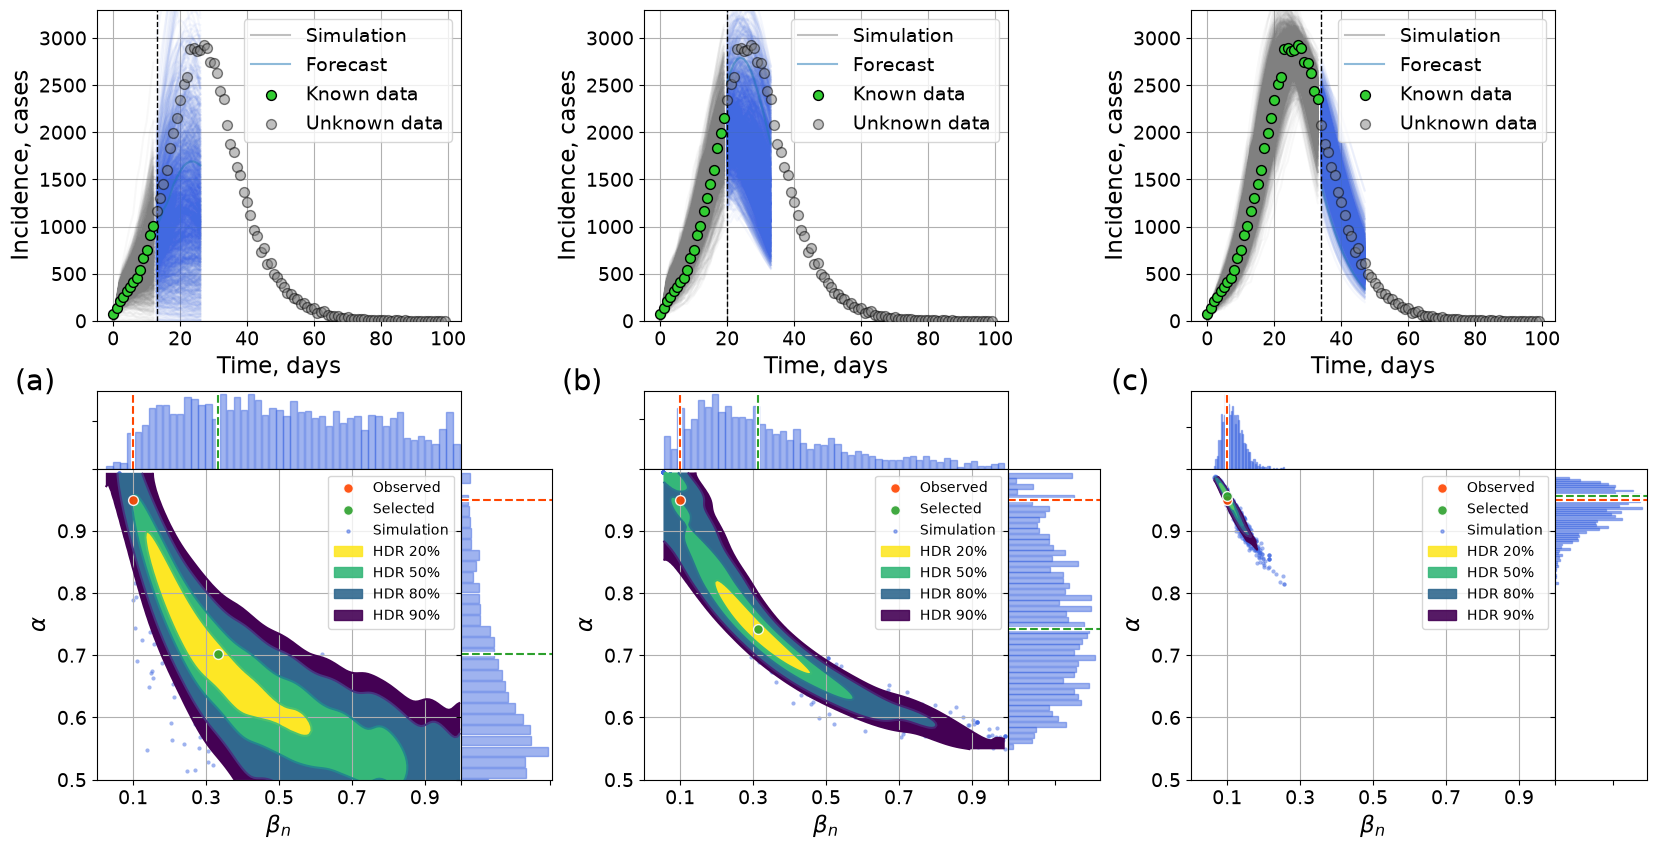

In [10]:
%%time
fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
with_switch=np.array(False) 
with_df=np.array(False) 
n_hyb_runs=1
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000
network_params=[with_switch,num_runs,frac,
                gamma,delta,n_nodes,top,koeff,shift]

idata14 = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_14b.nc")
idata7 = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_7b.nc")
idata0 = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_7a.nc")
k=3
for gs_0i, gs_1i, idata_i,idx  in zip([gs00,gs01,gs02],
                                 [gs10,gs11,gs12],
                         [idata14,idata7,idata0],
                                     np.arange(3)):
    
    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=True,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])
    fontsize=14
    ax_curves.annotate(labels[idx], xy=(0, 0), xycoords='axes fraction',
                           xytext=(-30, -50), textcoords='offset points',
                           fontsize=1.5*fontsize, ha='right', va='baseline')

#plt.savefig(f'results/ba_pred_eps1000.pdf', format='pdf', bbox_inches='tight')

### 3in1 forecast calibr SURROGARE plot

0.2779829297126548 0.736795497156399
sim plot time 1.5451502799987793
[0]
0.31522334807411323 0.731988870708796
sim plot time 0.7683396339416504
[0]
0.1126073935940733 0.9358820465310027
sim plot time 0.2184743881225586
[0]
CPU times: total: 4.47 s
Wall time: 4.49 s


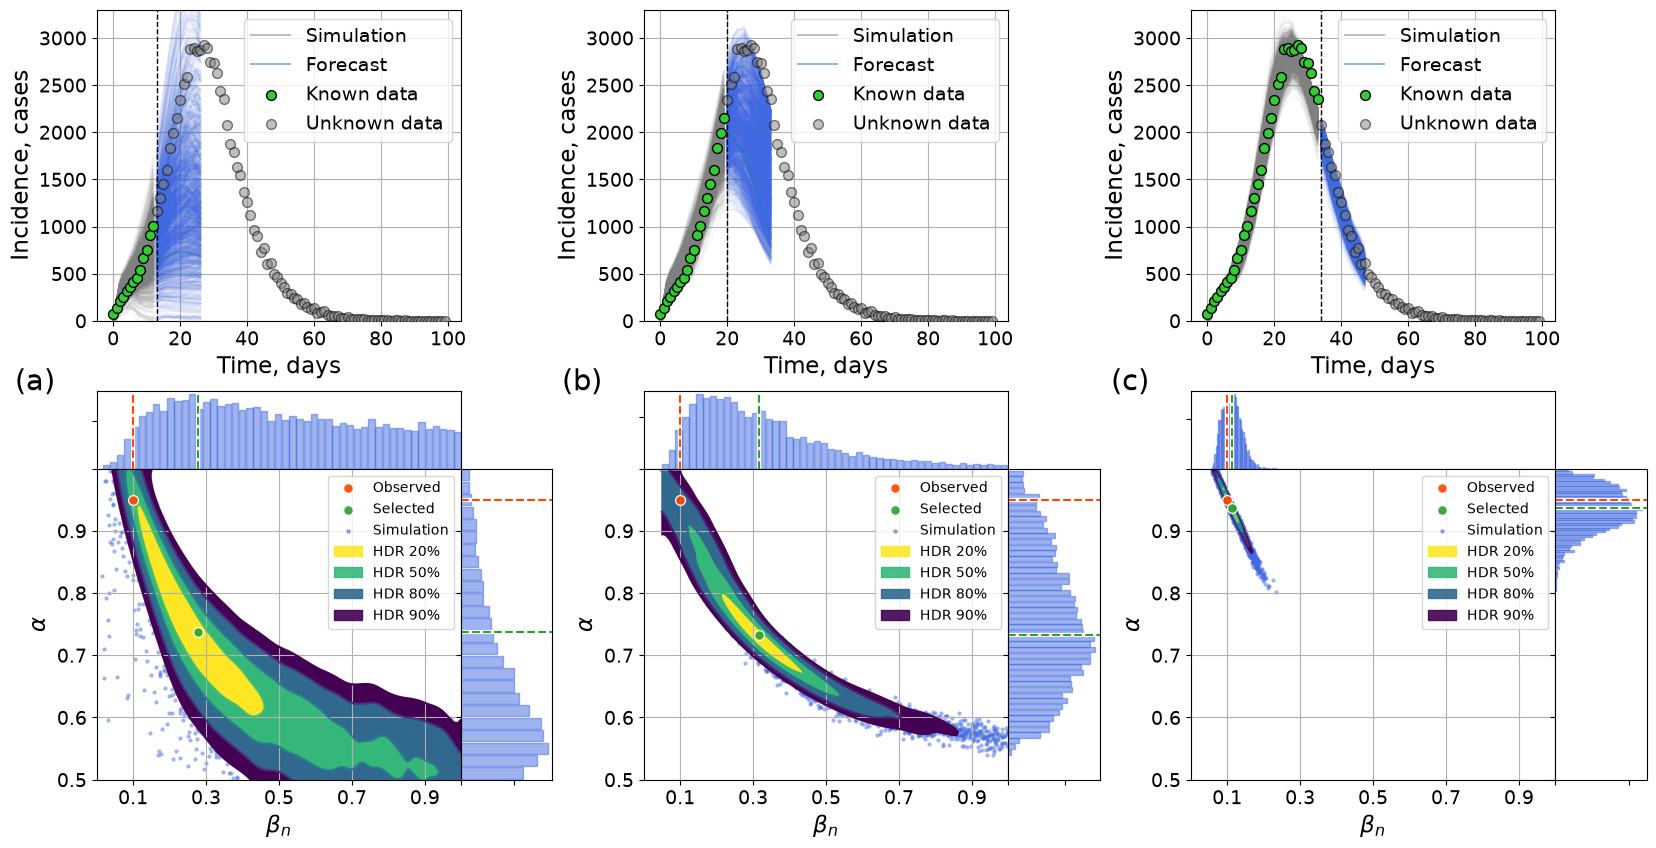

In [13]:
%%time
fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
with_switch=np.array(False) 
with_df=np.array(False) 
nth = 5
num_runs=[0]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000
network_params=[with_switch,num_runs,frac,
                gamma,delta,n_nodes,top,koeff,shift]

idata14 = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_14b.nc")
idata7 = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_7b.nc")
idata0 = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_7a.nc")
k=3


for gs_0i, gs_1i, idata_i,idx  in zip([gs00,gs01,gs02],
                                 [gs10,gs11,gs12],
                         [idata14,idata7,idata0],
                                     np.arange(3)):
    
    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=True,
                          nth=nth,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])
    fontsize=14
    ax_curves.annotate(labels[idx], xy=(0, 0), xycoords='axes fraction',
                           xytext=(-30, -50), textcoords='offset points',
                           fontsize=1.5*fontsize, ha='right', va='baseline')

#plt.savefig(f'results/ba_pred_eps1000.pdf', format='pdf', bbox_inches='tight')

### plot

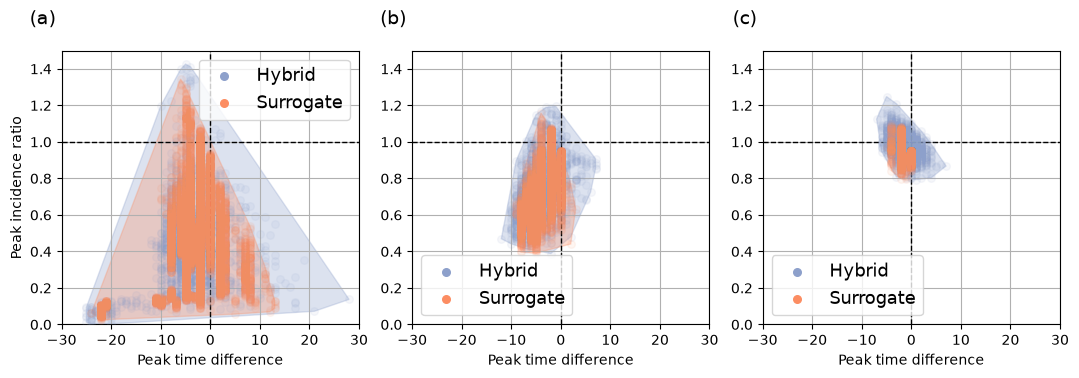

In [113]:
folder = 'hybrid_surr/calibr/'
observed_data = pd.read_csv(folder+'observed_incidence_a0.95_b0.1.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

idata14h = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_14b.nc")
idata14s = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_14b.nc")

idata7h = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_7b.nc")
idata7s = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_7b.nc")

idata7ah = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_7a.nc")
idata7as = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_7a.nc")
idatas = [[idata14h, idata14s],
          [idata7h, idata7s],
          [idata7ah, idata7as]
         ]
aux_f.create_peak_plot(folder_name=folder,
                     observed_data = observed_data,
                       idatas = idatas,
                     with_outliers=True, same_lims=True, 
                     figsize=(3.6*len(idatas),4), x_lim = (-30, 30), y_lim = (0, 1.5),
                     alpha_m=0.08, alpha_area=0.3, save=False)